
# KGE vs NSE: A Tutorial

In this notebook, we will explore the Kling-Gupta Efficiency (KGE) and Nash-Sutcliffe Efficiency (NSE) metrics, 
which are widely used to evaluate the performance of hydrological models. We'll see how KGE can provide a more 
comprehensive assessment compared to NSE.

## Overview
- **NSE**: Measures the relative magnitude of residual variance compared to the variance of the observed data.
- **KGE**: A metric that decomposes NSE into three components (correlation, bias, and variability).



## Equations

### Nash-Sutcliffe Efficiency (NSE)
\[
NSE = 1 - \frac{\sum_{i=1}^{n} (Q_{obs,i} - Q_{sim,i})^2}{\sum_{i=1}^{n} (Q_{obs,i} - \bar{Q}_{obs})^2}
\]
- \( Q_{obs} \) are observed values.
- \( Q_{sim} \) are simulated values.
- \( \bar{Q}_{obs} \) is the mean of observed values.

### Kling-Gupta Efficiency (KGE)
\[
KGE = 1 - \sqrt{(r-1)^2 + (\beta-1)^2 + (\gamma-1)^2}
\]
- \( r \): Linear correlation between observed and simulated values.
- \( \beta \): Bias ratio (mean of simulated / mean of observed).
- \( \gamma \): Variability ratio (coefficient of variation of simulated / coefficient of variation of observed).



## References
- Gupta, H. V., Kling, H., Yilmaz, K. K., & Martinez, G. F. (2009). Decomposition of the mean squared error and NSE performance criteria: Implications for improving hydrological modeling. *Journal of Hydrology*, 377(1-2), 80-91.
- Nash, J. E., & Sutcliffe, J. V. (1970). River flow forecasting through conceptual models part I—A discussion of principles. *Journal of Hydrology*, 10(3), 282-290.


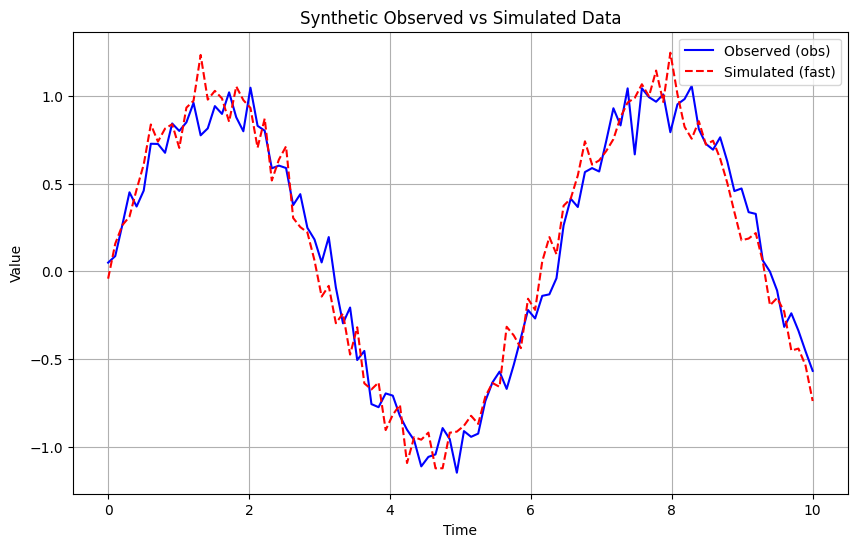

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic observed data (obs) - a sine wave with noise
np.random.seed(42)
time = np.linspace(0, 10, 100)
obs = np.sin(time) + np.random.normal(0, 0.1, len(time))

# Generate synthetic simulated data (fast) - slightly shifted sine wave with noise
fast_shifted = np.sin(time + 0.1) + np.random.normal(0, 0.1, len(time))

# Plot the synthetic data
plt.figure(figsize=(10, 6))
plt.plot(time, obs, label="Observed (obs)", color="blue")
plt.plot(time, fast_shifted, label="Simulated (fast)", color="red", linestyle="--")
plt.title("Synthetic Observed vs Simulated Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [2]:

# Function to calculate NSE
def calculate_nse(obs, sim):
    return 1 - np.sum((sim - obs) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

# Function to calculate KGE
def calculate_kge(obs, sim):
    r = np.corrcoef(obs, sim)[0, 1]
    beta = np.mean(sim) / np.mean(obs)
    gamma = (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))
    kge = 1 - np.sqrt((r - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2)
    return kge

# Calculate NSE and KGE for the synthetic data
nse_value = calculate_nse(obs, fast_shifted)
kge_value = calculate_kge(obs, fast_shifted)

nse_value, kge_value


(np.float64(0.9467542573379437), np.float64(0.9526986286244324))


## Comparison of NSE and KGE

The calculated values for the synthetic data are:
- **NSE (Nash-Sutcliffe Efficiency)**: ~0.947
- **KGE (Kling-Gupta Efficiency)**: ~0.953

Both metrics indicate a good match between the observed and simulated data. However, the KGE score is slightly higher, 
reflecting its ability to account for different aspects of the model's performance (e.g., correlation, bias, and variability).

### Why KGE is Often Preferred
KGE provides a more balanced assessment by considering:
- **Correlation (r)**: How well the timing of events matches between observed and simulated data.
- **Bias (β)**: The relative magnitude difference between observed and simulated data.
- **Variability (γ)**: The spread or variability of the data.

This makes KGE a more robust metric, especially in cases where NSE might be overly influenced by a single aspect of the model's performance.



## Conclusion

In this tutorial, we demonstrated the calculation and interpretation of the KGE and NSE metrics using synthetic data. 
While both metrics have their merits, KGE offers a more comprehensive view by incorporating correlation, bias, and 
variability. This makes it a valuable tool for evaluating model performance, particularly in hydrology.

Feel free to experiment with different synthetic data scenarios to further explore the differences between these metrics!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
def calculate_kge(obs, sim):
    """Calculates the Kling-Gupta Efficiency (KGE) score.

    Args:
        obs: Observed values.
        sim: Simulated values.

    Returns:
        KGE score.
    """

    # Calculate correlation coefficient
    rho = np.corrcoef(obs, sim)[0, 1]

    # Calculate bias
    bias = np.mean(sim - obs)

    # Calculate variance ratio
    var_ratio = np.var(sim) / np.var(obs)

    # Calculate KGE
    kge = 1 - np.sqrt((rho - 1)**2 + (bias / np.mean(obs))**2 + (var_ratio - 1)**2)

    return kge

def calculate_nse(obs, sim):
    """Calculates the Nash-Sutcliffe Efficiency (NSE) score.

    Args:
        obs: Observed values.
        sim: Simulated values.

    Returns:
        NSE score.
    """

    mse = mean_squared_error(obs, sim)
    var_obs = np.var(obs)
    nse = 1 - (mse / var_obs)
    return nse

## Generate synthetic data:

In [7]:
# Example: Generate synthetic data with varying levels of correlation, bias, and variance
np.random.seed(42)
obs = np.random.normal(loc=10, scale=2, size=1000)
sim_1 = obs + np.random.normal(loc=0, scale=0.5, size=1000)  # High correlation, low bias, low variance
sim_2 = obs + np.random.normal(loc=2, scale=1, size=1000)  # Medium correlation, high bias, medium variance
sim_3 = obs + np.random.normal(loc=0, scale=3, size=1000)  # Low correlation, low bias, high variance

### Calculate KGE and NSE:

In [8]:
kge_1 = calculate_kge(obs, sim_1)
kge_2 = calculate_kge(obs, sim_2)
kge_3 = calculate_kge(obs, sim_3)

nse_1 = calculate_nse(obs, sim_1)
nse_2 = calculate_nse(obs, sim_2)
nse_3 = calculate_nse(obs, sim_3)

## Visualize results:

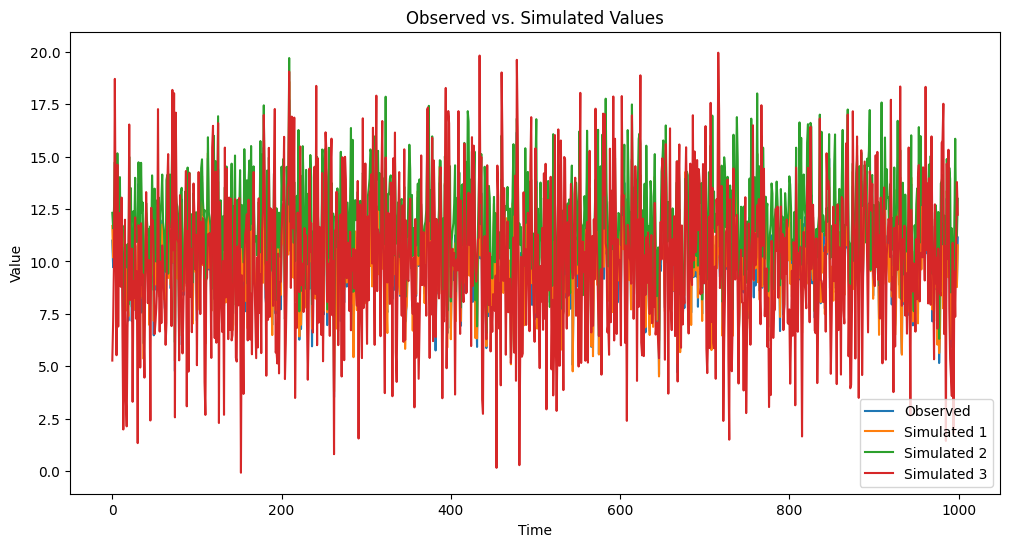

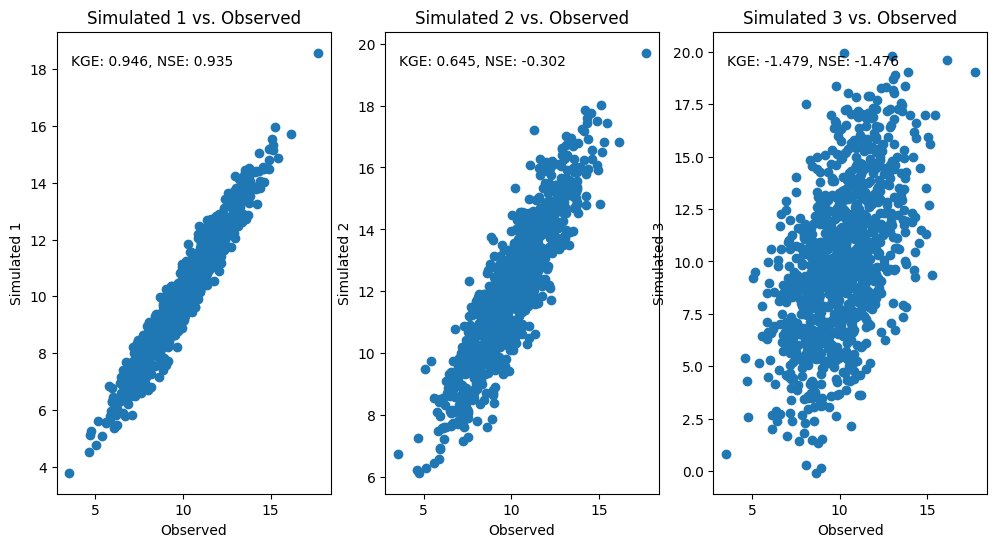

In [10]:
# Plot observed, simulated, and error values
plt.figure(figsize=(12, 6))
plt.plot(obs, label='Observed')
plt.plot(sim_1, label='Simulated 1')
plt.plot(sim_2, label='Simulated 2')
plt.plot(sim_3, label='Simulated 3')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Observed vs. Simulated Values')
plt.show()

# Create scatter plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(obs, sim_1)
plt.xlabel('Observed')
plt.ylabel('Simulated 1')
plt.title('Simulated 1 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_1:.3f}, NSE: {nse_1:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.subplot(1, 3, 2)
plt.scatter(obs, sim_2)
plt.xlabel('Observed')
plt.ylabel('Simulated 2')
plt.title('Simulated 2 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_2:.3f}, NSE: {nse_2:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.subplot(1, 3, 3)
plt.scatter(obs, sim_3)
plt.xlabel('Observed')
plt.ylabel('Simulated 3')
plt.title('Simulated 3 vs. Observed')
plt.text(0.05, 0.95, f'KGE: {kge_3:.3f}, NSE: {nse_3:.3f}', transform=plt.gca().transAxes, horizontalalignment='left', verticalalignment='top')


plt.show()

# Decomposiion of NSE

In [12]:
def nse_decompos(fcst,obs):
    r = np.corrcoef(obs, fcst)[0, 1]
    mu_fcst = np.mean(fcst)
    mu_obs = np.mean(obs)
    sigma_fcst = np.std(fcst)
    sigma_obs = np.std(obs)
    A = r**2
    B = (r - sigma_fcst/sigma_obs)**2
    C = ((mu_fcst-mu_obs)/sigma_obs)**2
    NSE = A - B - C
    return NSE, A, B, C


In [13]:
nse_decomp_1 = nse_decompos(sim_1,obs)
nse_decomp_2 = nse_decompos(sim_2,obs)
nse_decomp_3 = nse_decompos(sim_3,obs)

In [14]:
nse_decomp_1

(np.float64(0.9348227314666214),
 np.float64(0.9380008984961962),
 np.float64(0.0028507746628076503),
 np.float64(0.00032739236676702905))

In [15]:
nse_decomp_2

(np.float64(-0.30221318671099406),
 np.float64(0.8022232887044791),
 np.float64(0.05439212357133561),
 np.float64(1.0500443518441376))

In [16]:
nse_decomp_3

(np.float64(-1.4764120126641116),
 np.float64(0.27915332775418217),
 np.float64(1.7547422728738233),
 np.float64(0.0008230675444705412))

In [18]:
nse_1,nse_2,nse_3

(np.float64(0.9348227314666213),
 np.float64(-0.3022131867109932),
 np.float64(-1.4764120126641127))

In [20]:
np.allclose(nse_1,nse_decomp_1[0])

True

In [21]:
np.allclose(nse_2,nse_decomp_2[0])

True

In [22]:
np.allclose(nse_3,nse_decomp_3[0])

True